# Chapter 7 — Dimensionality Reduction

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import fetch_openml, make_swiss_roll, make_blobs
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## The Curse of Dimensionality

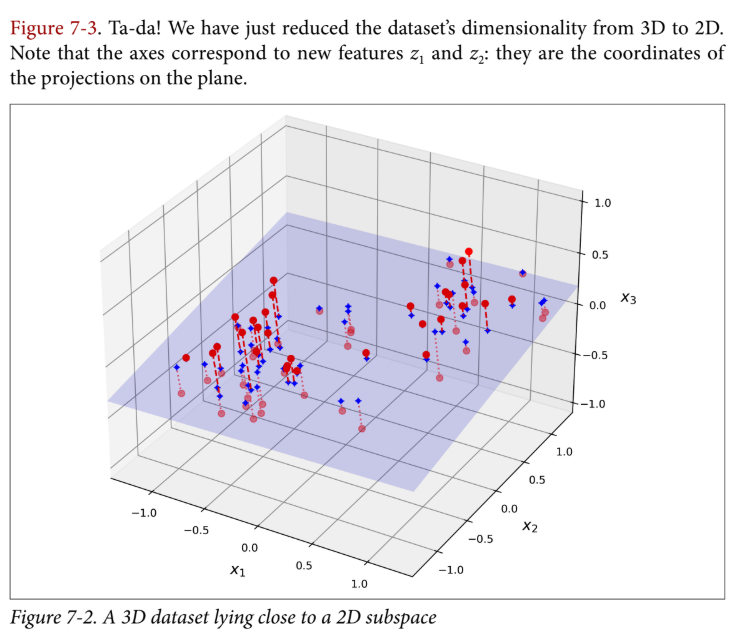

## Manifold Learning

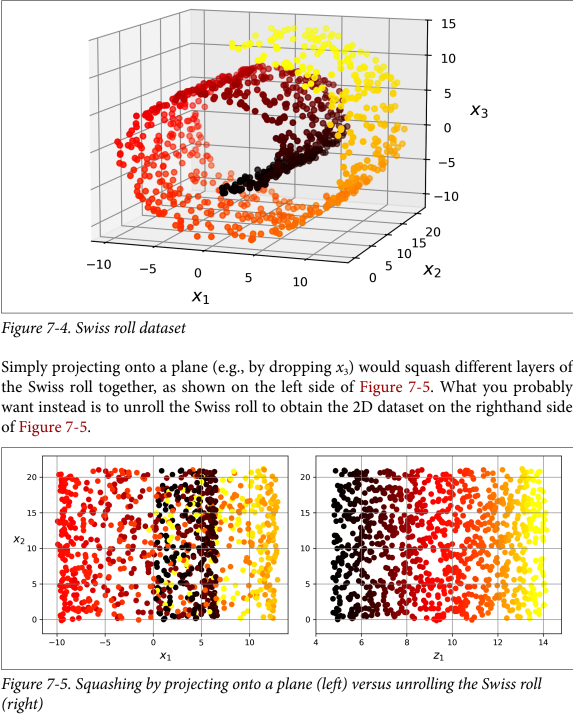

## PCA

### Preserving the Variance

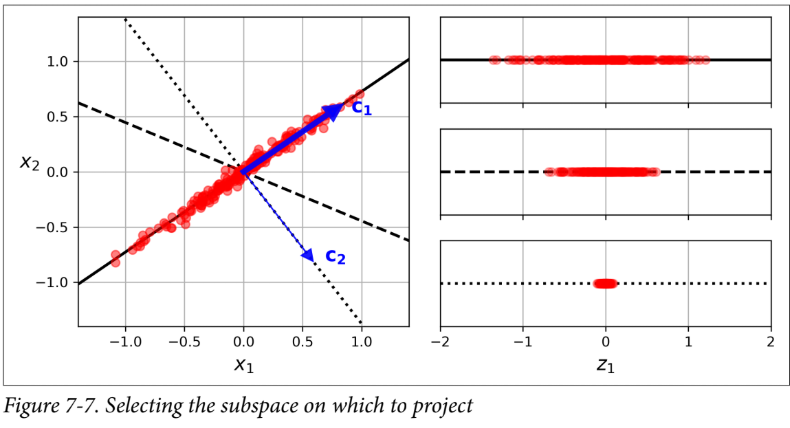

## Principal Components

In [2]:
import numpy as np 

# create a small 3D dataset
X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])
# Center the data by subtracting the mean
X_centered = X - np.mean(X, axis=0)
U, s, Vt = np.linalg.svd(X_centered)
# Project the data onto the first two principal components
c1 = Vt[0]  # First principal component
c2 = Vt[1]  # Second principal component

In [3]:
print("First principal component (c1):", c1)
print("Second principal component (c2):", c2)

First principal component (c1): [0.57735027 0.57735027 0.57735027]
Second principal component (c2): [ 0.81649658 -0.40824829 -0.40824829]


### Projecting Down to d Dimensions

projecting the training set down to d dimensions where d < n is like:

$$\mathbf{Z} = \mathbf{X} \mathbf{W}_d$$

In [4]:
W2 = Vt[:2].T  # Take the first two principal components
X2D = X_centered.dot(W2)  # Project the data onto the first two principal components
print("Projected data (X2D):\n", X2D)

Projected data (X2D):
 [[-7.79422863e+00 -2.38697950e-15]
 [-2.59807621e+00 -6.10622664e-16]
 [ 2.59807621e+00  6.10622664e-16]
 [ 7.79422863e+00  2.38697950e-15]]


### Using Scikit-Learn

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X_centered)
print("Projected data (X2D) using Scikit-Learn:\n", X2D)

Projected data (X2D) using Scikit-Learn:
 [[-7.79422863e+00 -3.57338929e-17]
 [-2.59807621e+00  9.74560715e-18]
 [ 2.59807621e+00 -9.74560715e-18]
 [ 7.79422863e+00 -2.92368214e-17]]


### Explained Variance Ratio

In [6]:
pca.explained_variance_ratio_

array([1.00000000e+00, 1.71974559e-35])

### Choosing the Right Number of Dimensions

In [7]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
print("Number of dimensions to retain 95% variance:", d)

Number of dimensions to retain 95% variance: 154


In [8]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
print("Shape of the reduced dataset:", X_reduced.shape)

Shape of the reduced dataset: (60000, 154)


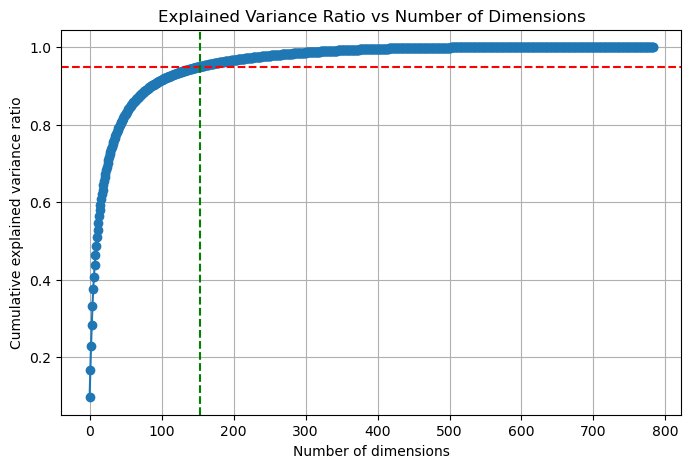

In [9]:
# plot dimensions vs explained variance ratio
plt.figure(figsize=(8, 5))
plt.plot(cumsum, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.axvline(x=d, color='g', linestyle='--')
plt.xlabel('Number of dimensions')
plt.ylabel('Cumulative explained variance ratio')
plt.title('Explained Variance Ratio vs Number of Dimensions')
plt.grid()
plt.show()


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42), RandomForestClassifier(random_state=42))

param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}

rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3, random_state=42)

rnd_search.fit(X_train[:2000], y_train[:2000])  # Using a subset for faster training

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': array([10, 11... 78, 79]), 'randomforestclassifier__n_estimators': array([ 50, ...97, 498, 499])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [11]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


## PCA for Compression

In [12]:
X_recovered = pca.inverse_transform(X_reduced)
print("Shape of the recovered dataset:", X_recovered.shape)

Shape of the recovered dataset: (60000, 784)


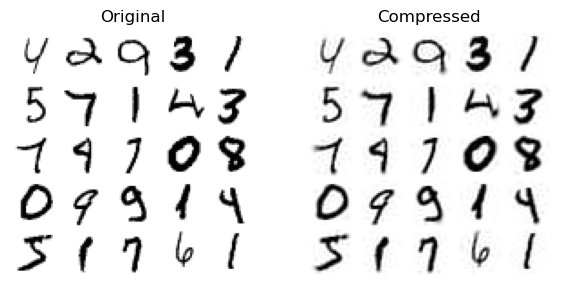

In [13]:
# extra code – this cell generates Figure 7–9

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")



The equation for the inverse transformation is shown in:

$$\mathbf{X}_{recovered} = \mathbf{X}_{projected} \mathbf{W}^T_d$$

## Randomized PCA

Cuando trabajas con datasets de alta dimensionalidad ($n$ muy grande) pero solo necesitas conservar un número pequeño de componentes ($d$), el PCA estándar (Full SVD) se vuelve extremadamente lento. Scikit-Learn ofrece el **PCA aleatorizado**, un algoritmo estocástico que encuentra una aproximación rápida de los primeros componentes.

#### Comparativa de Complejidad Computacional
La clave de su velocidad es que la complejidad ya no escala con el cuadrado de todas las características originales ($n$), sino con las que quieres mantener ($d$)[cite: 1]:

*   **SVD Completo (Estándar)**: $O(m \times n^2) + O(n^3)$[cite: 1]
*   **PCA Aleatorizado**: $O(m \times d^2) + O(d^3)$[cite: 1]

si n = 784 y d = 154, entonces: 
*   **SVD Completo**: $O(m \times 784^2) + O(784^3)$ = $O(m \times 614656) + O(482344704)$
*   **PCA Aleatorizado**: $O(m \times 154^2) + O(154^3)$ = $O(m \times 23716) + O(3652264)$


In [14]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)
print("Shape of the reduced dataset using Randomized PCA:", X_reduced.shape)

Shape of the reduced dataset using Randomized PCA: (60000, 154)


## Incremental PCA

In [15]:
from sklearn.decomposition import IncrementalPCA
n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)
X_reduced = inc_pca.transform(X_train)


In [16]:
X_reduced.shape

(60000, 154)

In [17]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

In [18]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",154
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",600


## Random Projection

In [19]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, ε = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=ε)
d

np.int64(7300)

In [20]:
n = 20_000
rng = np.random.default_rng(42)
P = rng.standard_normal((d, n)) / np.sqrt(d) # std dev = sqrt(variance)
X = rng.standard_normal((m, n)) # create a random dataset with 10,000 features
X_reduced = X @ P.T
print("Shape of the reduced dataset using random projection:", X_reduced.shape)

Shape of the reduced dataset using random projection: (5000, 7300)


In [21]:
X_reduced[:5]

array([[-1.48815917, -3.62815598,  0.7379008 , ..., -0.44688292,
        -1.17048773,  1.417168  ],
       [-0.87041112,  0.48048372,  2.48193767, ...,  0.84169096,
         1.7772766 ,  0.78821933],
       [ 1.40928784, -0.08104836, -0.66345378, ...,  0.08340796,
         0.53364951,  0.06951773],
       [ 0.74084976, -1.28959836, -0.04250991, ...,  1.38555225,
         0.3936993 , -1.23776758],
       [ 0.49926426,  0.58473317,  2.26936768, ..., -1.06912471,
        -1.40192305, -1.45761838]], shape=(5, 7300))

Para esta metodología solo ocupas el tamaño del dataset original y el pocentaje de distancia 'e' que quieres conservar, y el algoritmo se encarga de generar una matriz de proyección aleatoria que cumple con esa condición.

In [22]:
from sklearn.random_projection import GaussianRandomProjection
grp = GaussianRandomProjection(eps=ε, random_state=42)
X_reduced = grp.fit_transform(X)
print("Shape of the reduced dataset using GaussianRandomProjection:", X_reduced.shape)

Shape of the reduced dataset using GaussianRandomProjection: (5000, 7300)


In [23]:
X_reduced[:5]

array([[ 1.69408337,  2.41661036, -4.5860355 , ..., -1.78339069,
         1.42895041,  0.74108623],
       [ 0.71333804,  2.361083  , -2.16506292, ...,  0.49408746,
         1.74363846,  3.16601553],
       [ 0.28760118, -0.35310548,  1.87177017, ..., -1.69895869,
         1.16883402,  1.46712174],
       [-0.53434123, -0.01981392, -0.20899374, ...,  3.03753145,
         1.91117996, -1.32372502],
       [ 0.7303305 ,  0.50898654,  0.19732381, ...,  0.84507545,
        -2.11095091, -0.02257491]], shape=(5, 7300))

In [24]:
from sklearn.random_projection import SparseRandomProjection
srp = SparseRandomProjection(eps=ε, random_state=42)
X_reduced = srp.fit_transform(X)
print("Shape of the reduced dataset using SparseRandomProjection:", X_reduced.shape)

Shape of the reduced dataset using SparseRandomProjection: (5000, 7300)


In [26]:
X_reduced[:5]

array([[-0.40936431,  1.27856587,  0.02939372, ..., -0.52061009,
        -1.19916479,  0.80160764],
       [ 0.82787042, -0.82222429,  0.5319649 , ...,  1.33190027,
         3.49786015, -3.31577453],
       [ 0.43932149,  1.15645016, -2.31311527, ..., -0.10164793,
        -2.29650155,  0.79594383],
       [ 0.73928316,  1.23973158,  0.15823022, ..., -0.52691841,
         2.53983737,  1.01624049],
       [ 0.96865892, -1.93170804, -0.55822303, ..., -2.01708456,
         0.9739855 , -0.32957591]], shape=(5, 7300))

## LLE

In [35]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)
print("Shape of the unrolled dataset using LLE:", X_unrolled.shape)

Shape of the unrolled dataset using LLE: (1000, 2)


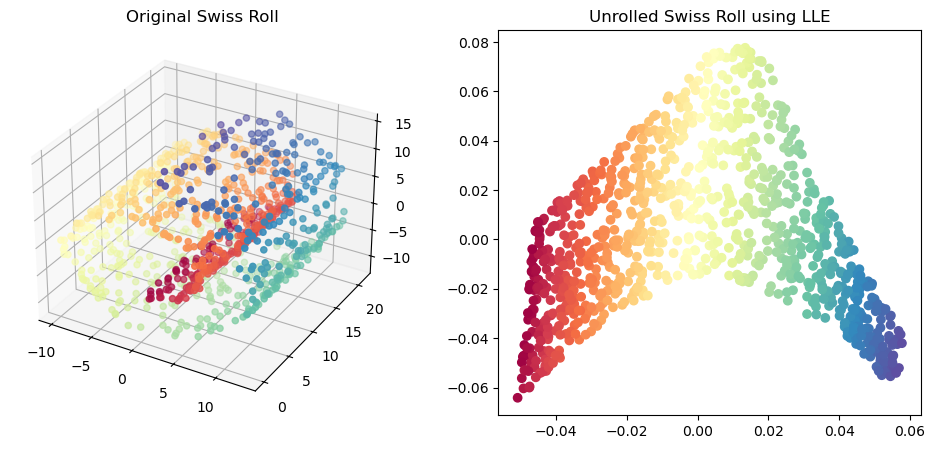

In [36]:
# plot the original in 3D and the unrolled datasets
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll")
ax = fig.add_subplot(122)
ax.scatter(X_unrolled[:, 0], X_unrolled[:, 1], c=t, cmap=plt.cm.Spectral)
ax.set_title("Unrolled Swiss Roll using LLE")
plt.show()

In [37]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

c:\Users\evolu\Desktop\Master\Ml_Torch_Sklrn\.conda\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\evolu\Desktop\Master\Ml_Torch_Sklrn\.conda\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [38]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

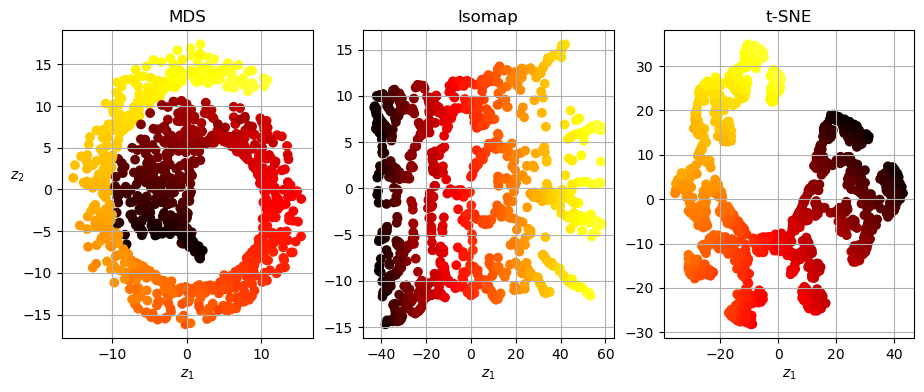

In [41]:
# extra code – this cell generates Figure 7–11
from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))
titles = ["MDS", "Isomap", "t-SNE"]
plt.figure(figsize=(11, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid(True)


plt.show()